# **Project 2 - Keyword Spotter**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create dataset split
"""

import os, random, shutil

src = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples"
dst = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/dataset"

splits = ["train", "val", "test"]
ratios = [0.7, 0.15, 0.15]

for word in os.listdir(src):
    files = os.listdir(os.path.join(src, word))
    random.shuffle(files)

    n = len(files)
    train_end = int(0.7 * n)
    val_end = train_end + int(0.15 * n)

    split_map = {
        "train": files[:train_end],
        "val": files[train_end:val_end],
        "test": files[val_end:]
    }

    for split in splits:
        out_dir = os.path.join(dst, split, word)
        os.makedirs(out_dir, exist_ok=True)

        for f in split_map[split]:
            shutil.copy(os.path.join(src, word, f),
                        os.path.join(out_dir, f))
"""

'\n\nimport os, random, shutil\n\nsrc = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples"\ndst = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/dataset"\n\nsplits = ["train", "val", "test"]\nratios = [0.7, 0.15, 0.15]\n\nfor word in os.listdir(src):\n    files = os.listdir(os.path.join(src, word))\n    random.shuffle(files)\n\n    n = len(files)\n    train_end = int(0.7 * n)\n    val_end = train_end + int(0.15 * n)\n\n    split_map = {\n        "train": files[:train_end],\n        "val": files[train_end:val_end],\n        "test": files[val_end:]\n    }\n\n    for split in splits:\n        out_dir = os.path.join(dst, split, word)\n        os.makedirs(out_dir, exist_ok=True)\n\n        for f in split_map[split]:\n            shutil.copy(os.path.join(src, word, f),\n                        os.path.join(out_dir, f))\n'

### **Model Training**

In [2]:
DATASET_PATH = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/dataset"

In [17]:
import tensorflow as tf

train_ds = tf.keras.utils.audio_dataset_from_directory(
    DATASET_PATH + "/train",
    batch_size=32,
    output_sequence_length=16000
)

val_ds = tf.keras.utils.audio_dataset_from_directory(
    DATASET_PATH + "/val",
    batch_size=32,
    output_sequence_length=16000
)

Found 322 files belonging to 3 classes.
Found 67 files belonging to 3 classes.


In [18]:
def preprocess(audio, label):
    audio = tf.squeeze(audio, axis=-1)
    spectrogram = tf.abs(tf.signal.stft(audio, 256, 128))
    return spectrogram, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(124, 129)),
    tf.keras.layers.Reshape((124, 129, 1)),

    tf.keras.layers.Conv2D(6, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(12, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [21]:
print("Input shape:", model.input_shape)

Input shape: (None, 124, 129)


In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6180 - loss: 0.8885 - val_accuracy: 0.8955 - val_loss: 0.6640
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8789 - loss: 0.5879 - val_accuracy: 0.8806 - val_loss: 0.4447
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9099 - loss: 0.3607 - val_accuracy: 0.9104 - val_loss: 0.3853
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9379 - loss: 0.2462 - val_accuracy: 0.8806 - val_loss: 0.4189
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9534 - loss: 0.1619 - val_accuracy: 0.8955 - val_loss: 0.3842
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9596 - loss: 0.1596 - val_accuracy: 0.9403 - val_loss: 0.3401
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.9224 - loss: 0.2350 - val_accuracy: 0.9104 - val_loss: 0.3795
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9503 - loss: 0.1325 - val_accuracy: 0.89

In [23]:
print("Accuracy:", history.history['accuracy'][-1])
print("Val Accuracy:", history.history['val_accuracy'][-1])

Accuracy: 0.9813664555549622
Val Accuracy: 0.9552238583564758


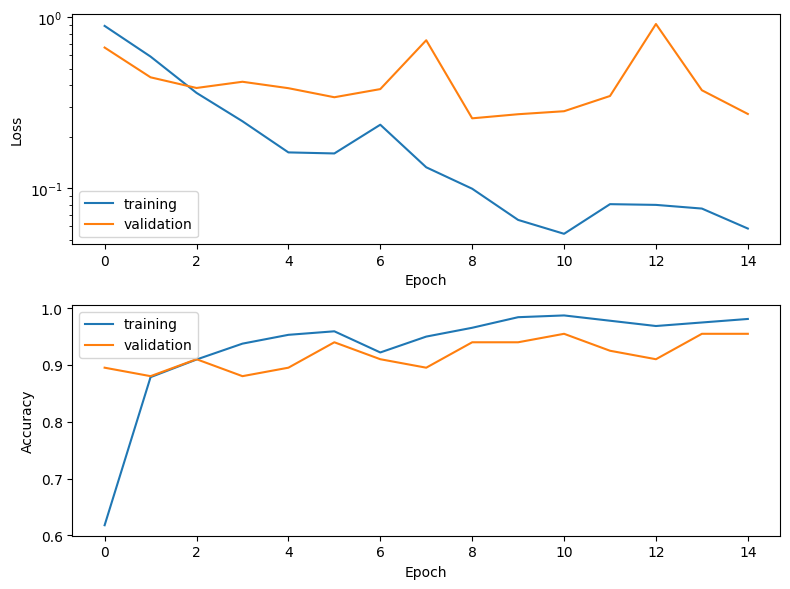

In [25]:
import matplotlib.pyplot as plt

metrics = history.history

plt.figure(figsize=(8,6))

# Loss (top)
plt.subplot(2,1,1)
plt.semilogy(history.epoch, metrics['loss'], label='training')
plt.semilogy(history.epoch, metrics['val_loss'], label='validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Accuracy (bottom)
plt.subplot(2,1,2)
plt.plot(history.epoch, metrics['accuracy'], label='training')
plt.plot(history.epoch, metrics['val_accuracy'], label='validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

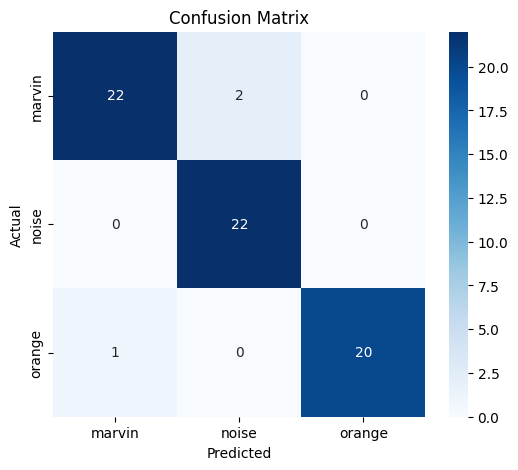

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['marvin', 'noise', 'orange']

y_true, y_pred = [], []

for x, y in val_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

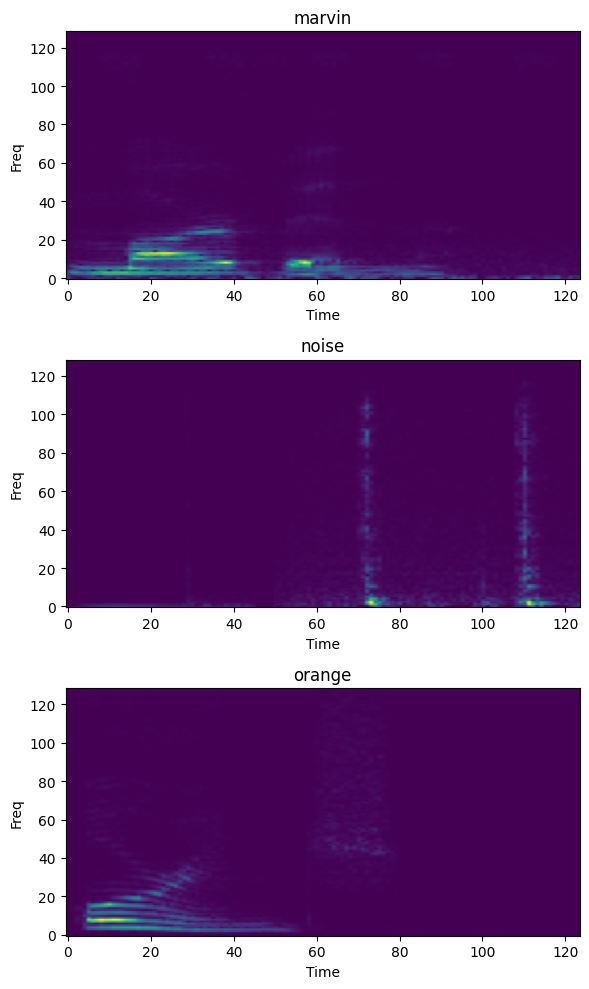

In [33]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['marvin', 'noise', 'orange']

# store one example per class
samples = {}

for x, y in val_ds:
    for i in range(len(y)):
        label = labels[y[i]]
        if label not in samples:
            samples[label] = x[i].numpy()
        if len(samples) == 3:
            break
    if len(samples) == 3:
        break

plt.figure(figsize=(6,10))  # taller figure

for i, label in enumerate(labels):
    plt.subplot(3,1,i+1)  # <-- vertical stack
    plt.imshow(samples[label].T, aspect='auto', origin='lower')
    plt.title(label)
    plt.xlabel("Time")
    plt.ylabel("Freq")

plt.tight_layout()
plt.show()

In [27]:
test_ds = tf.keras.utils.audio_dataset_from_directory(
    DATASET_PATH + "/test",
    batch_size=32,
    output_sequence_length=16000
)

test_ds = test_ds.map(preprocess)

model.evaluate(test_ds)

Found 73 files belonging to 3 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9452 - loss: 0.5355


[0.5355271697044373, 0.9452054500579834]

### **Model Conversion**

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

import os
save_path = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_2"
os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, "model.tflite"), "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpnre0yr14'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 124, 129), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139963933575312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933575696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933576272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933574352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933576656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933574928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933573968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933577232: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
def representative_data_gen():
    for audio, _ in train_ds.take(100):
        yield [audio]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

with open(os.path.join(save_path, "model_quant_int8.tflite"), "wb") as f:
    f.write(tflite_quant_model)

Saved artifact at '/tmp/tmpxacsbogv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 124, 129), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139963933575312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933575696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933576272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933574352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933576656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933574928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933573968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139963933577232: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
!xxd -i "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_2/model_quant_int8.tflite" > "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_2/model_data.cc"

### **Metrics and Model Summary**

In [34]:
print("Train acc:", history.history['accuracy'][-1])
print("Val acc:", history.history['val_accuracy'][-1])

test_loss, test_acc = model.evaluate(test_ds)
print("Test acc:", test_acc)
print("Test loss:", test_loss)

Train acc: 0.9813664555549622
Val acc: 0.9552238583564758
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.9452 - loss: 0.5355
Test acc: 0.9452054500579834
Test loss: 0.535527229309082


In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 124, 129, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 122, 127, 6)    │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 61, 63, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 59, 61, 12)     │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 29, 30, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │       250,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 754,139 (2.88 MB)

 Trainable params: 251,379 (981.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 502,760 (1.92 MB)

In [ ]:
import os

size_kb = os.path.getsize(
    "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_2/model_quant_int8.tflite"
) / 1024

print("Model size (KB):", size_kb)

Model size (KB): 251.9609375


In [36]:
print("Input shape:", model.input_shape)

Input shape: (None, 124, 129)


In [37]:
class_names = ["marvin", "noise", "orange"]

for audio, labels in test_ds.take(1):
    preds = model.predict(audio)

    for i in range(5):
        pred_class = class_names[preds[i].argmax()]
        confidence = preds[i].max()
        true_class = class_names[labels[i].numpy()]

        print(f"True: {true_class} | Pred: {pred_class} | Conf: {confidence:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
True: noise | Pred: noise | Conf: 0.995
True: noise | Pred: noise | Conf: 0.964
True: orange | Pred: orange | Conf: 1.000
True: marvin | Pred: marvin | Conf: 1.000
True: marvin | Pred: marvin | Conf: 0.987


In [38]:
# False Rejection Rate (FRR)
import numpy as np

def compute_frr(target_class_idx):
    total = 0
    missed = 0

    for audio, labels in test_ds:
        preds = model.predict(audio)
        pred_classes = np.argmax(preds, axis=1)

        for i in range(len(labels)):
            if labels[i] == target_class_idx:
                total += 1
                if pred_classes[i] != target_class_idx:
                    missed += 1

    return missed / total

# order: ["marvin", "noise", "orange"]
frr_marvin = compute_frr(0)
frr_orange = compute_frr(2)

print("FRR marvin:", frr_marvin)
print("FRR orange:", frr_orange)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
FRR marvin: 0.07692307692307693
FRR orange: 0.08695652173913043
